# TASK 01

Heuristic values (Euclidean distance to Packing Station):
--------------------------------------------------
h(Receiving_Area) = 10.0
h(Aisle_A) = 7.81
h(Aisle_B) = 5.39
h(Storage) = 5.0
h(Quality_Check) = 2.24
h(Packing_Station) = 0.0

Admissibility check (h(n) <= cost + h(m)):
--------------------------------------------------
h(Receiving_Area)=10.0 <= 3 + h(Aisle_A)=7.81? True
h(Aisle_A)=7.81 <= 4 + h(Aisle_B)=5.39? True
h(Aisle_A)=7.81 <= 5 + h(Storage)=5.0? True
h(Aisle_B)=5.39 <= 3 + h(Quality_Check)=2.24? False
h(Storage)=5.0 <= 2 + h(Quality_Check)=2.24? False
h(Quality_Check)=2.24 <= 2 + h(Packing_Station)=0.0? False
h(Aisle_B)=5.39 <= 3 + h(Storage)=5.0? True


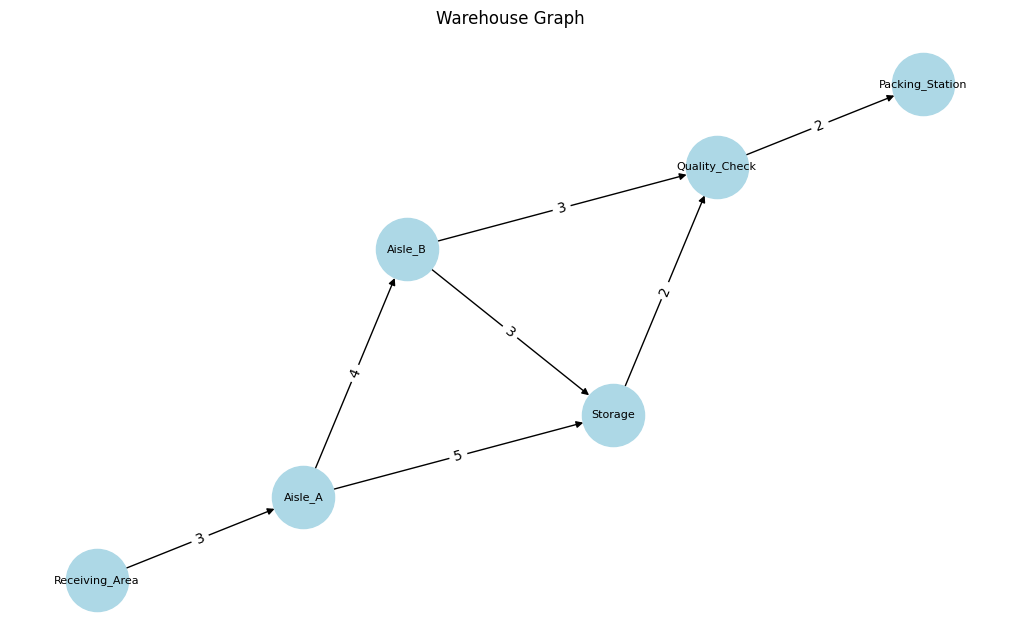

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import math

coords = {
    "Receiving_Area": (0, 0),
    "Aisle_A": (2, 1),
    "Aisle_B": (3, 4),
    "Storage": (5, 2),
    "Quality_Check": (6, 5),
    "Packing_Station": (8, 6)
}

edges = [
    ("Receiving_Area", "Aisle_A", 3),
    ("Aisle_A", "Aisle_B", 4),
    ("Aisle_A", "Storage", 5),
    ("Aisle_B", "Quality_Check", 3),
    ("Storage", "Quality_Check", 2),
    ("Quality_Check", "Packing_Station", 2),
    ("Aisle_B", "Storage", 3)
]

def h(node, goal):
    x1, y1 = coords[node]
    x2, y2 = coords[goal]
    return round(math.sqrt((x2-x1)**2 + (y2-y1)**2), 2)

goal = "Packing_Station"
start = "Receiving_Area"

print("Heuristic values (Euclidean distance to Packing Station):")
print("-" * 50)
for node in coords:
    print(f"h({node}) = {h(node, goal)}")

print("\nAdmissibility check (h(n) <= cost + h(m)):")
print("-" * 50)
for u, v, cost in edges:
    print(f"h({u})={h(u,goal)} <= {cost} + h({v})={h(v,goal)}? {h(u,goal) <= cost + h(v,goal)}")

G = nx.DiGraph()
for u, v, c in edges:
    G.add_edge(u, v, weight=c)

pos = coords
plt.figure(figsize=(10, 6))
nx.draw(G, pos, with_labels=True, node_color="lightblue",
        node_size=2000, font_size=8, arrows=True)
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.title("Warehouse Graph")
plt.axis("off")
plt.show()

# task 02


GBFS Node Expansion Order: ['Baggage_Area', 'Check_In', 'Food_Court', 'Departure_Gate']
Solution Path: Baggage_Area -> Check_In -> Food_Court -> Departure_Gate
Total Cost: 13


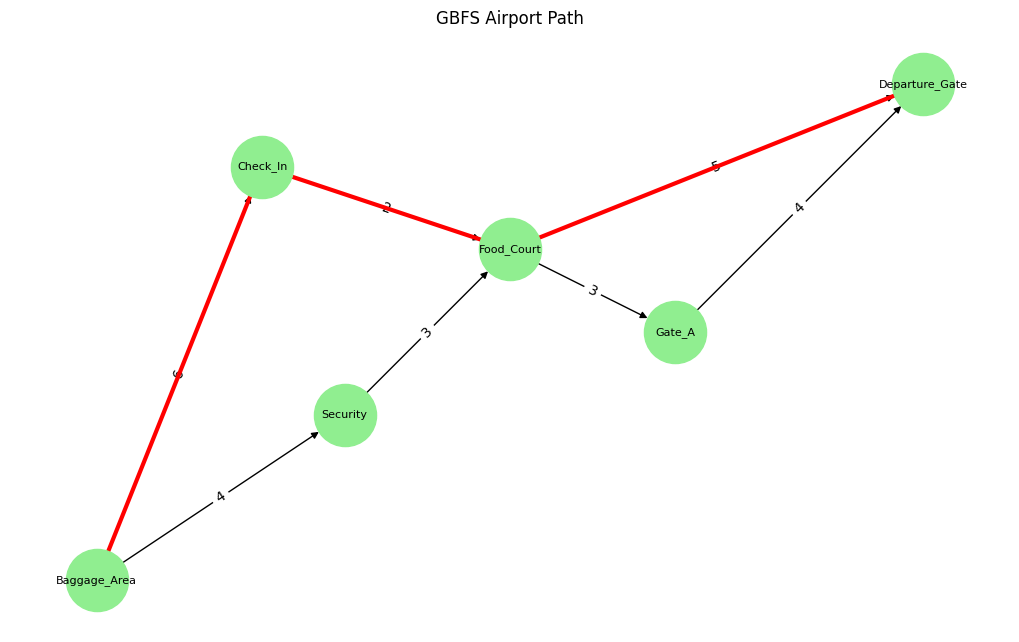

In [2]:
import heapq
import math
import networkx as nx
import matplotlib.pyplot as plt

coords = {
    "Baggage_Area": (0, 0),
    "Security": (3, 2),
    "Check_In": (2, 5),
    "Food_Court": (5, 4),
    "Gate_A": (7, 3),
    "Departure_Gate": (10, 6)
}

edges = [
    ("Baggage_Area", "Security", 4),
    ("Baggage_Area", "Check_In", 6),
    ("Security", "Food_Court", 3),
    ("Check_In", "Food_Court", 2),
    ("Food_Court", "Gate_A", 3),
    ("Gate_A", "Departure_Gate", 4),
    ("Food_Court", "Departure_Gate", 5)
]

def h(node, goal):
    x1, y1 = coords[node]
    x2, y2 = coords[goal]
    return math.sqrt((x2-x1)**2 + (y2-y1)**2)

def gbfs(graph, start, goal):
    pq = [(h(start, goal), start)]
    visited = set()
    parent = {start: None}
    order = []
    
    while pq:
        _, current = heapq.heappop(pq)
        if current in visited:
            continue
        visited.add(current)
        order.append(current)
        
        if current == goal:
            break
        
        for u, v, cost in graph:
            if u == current and v not in visited:
                heapq.heappush(pq, (h(v, goal), v))
                if v not in parent:
                    parent[v] = current
    
    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent.get(node)
    path.reverse()
    return path, order

start = "Baggage_Area"
goal = "Departure_Gate"
path, order = gbfs(edges, start, goal)

print("GBFS Node Expansion Order:", order)
print("Solution Path:", " -> ".join(path))

total_cost = 0
for i in range(len(path) - 1):
    for u, v, c in edges:
        if u == path[i] and v == path[i+1]:
            total_cost += c
print("Total Cost:", total_cost)

G = nx.DiGraph()
for u, v, c in edges:
    G.add_edge(u, v, weight=c)

plt.figure(figsize=(10, 6))
nx.draw(G, coords, with_labels=True, node_color="lightgreen",
        node_size=2000, font_size=8, arrows=True)
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, coords, edge_labels=labels)

path_edges = list(zip(path, path[1:]))
nx.draw_networkx_edges(G, coords, edgelist=path_edges,
                        edge_color="red", width=3, arrows=True)
plt.title("GBFS Airport Path")
plt.axis("off")
plt.show()

# TASK 03

A* Expansion Order (node, g, h, f):
  Pharmacy: g=0, h=9.43, f=9.43
  Corridor_A: g=3, h=6.32, f=9.32
  Nurse_Station: g=6, h=3.16, f=9.16
  Corridor_B: g=4, h=5.66, f=9.66
  Emergency_Ward: g=10, h=0.0, f=10.0

Solution Path: Pharmacy -> Corridor_B -> Emergency_Ward
Total Cost: 10


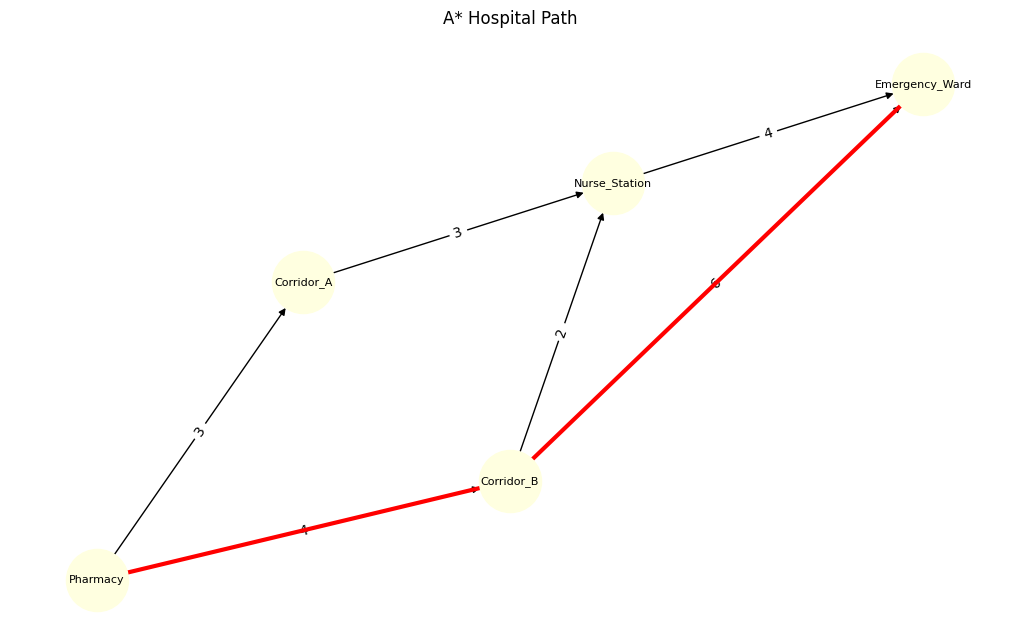

In [3]:
import heapq
import math
import networkx as nx
import matplotlib.pyplot as plt

coords = {
    "Pharmacy": (0, 0),
    "Corridor_A": (2, 3),
    "Corridor_B": (4, 1),
    "Nurse_Station": (5, 4),
    "Emergency_Ward": (8, 5)
}

edges = [
    ("Pharmacy", "Corridor_A", 3),
    ("Pharmacy", "Corridor_B", 4),
    ("Corridor_A", "Nurse_Station", 3),
    ("Corridor_B", "Nurse_Station", 2),
    ("Nurse_Station", "Emergency_Ward", 4),
    ("Corridor_B", "Emergency_Ward", 6)
]

def h(node, goal):
    x1, y1 = coords[node]
    x2, y2 = coords[goal]
    return round(math.sqrt((x2-x1)**2 + (y2-y1)**2), 2)

def astar(graph, start, goal):
    pq = [(0 + h(start, goal), 0, start, None)]
    visited = {}
    parent = {}
    order = []
    
    while pq:
        f, g, current, came_from = heapq.heappop(pq)
        if current in visited:
            continue
        visited[current] = g
        parent[current] = came_from
        order.append((current, g, h(current, goal), f))
        
        if current == goal:
            break
        
        for u, v, cost in graph:
            if u == current and v not in visited:
                new_g = g + cost
                new_f = new_g + h(v, goal)
                heapq.heappush(pq, (new_f, new_g, v, current))
    
    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent.get(node)
    path.reverse()
    return path, order, visited

start = "Pharmacy"
goal = "Emergency_Ward"
path, order, costs = astar(edges, start, goal)

print("A* Expansion Order (node, g, h, f):")
for o in order:
    print(f"  {o[0]}: g={o[1]}, h={o[2]}, f={o[3]}")

print("\nSolution Path:", " -> ".join(path))
print("Total Cost:", costs[goal])

G = nx.DiGraph()
for u, v, c in edges:
    G.add_edge(u, v, weight=c)

plt.figure(figsize=(10, 6))
nx.draw(G, coords, with_labels=True, node_color="lightyellow",
        node_size=2000, font_size=8, arrows=True)
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, coords, edge_labels=labels)

path_edges = list(zip(path, path[1:]))
nx.draw_networkx_edges(G, coords, edgelist=path_edges,
                        edge_color="red", width=3, arrows=True)
plt.title("A* Hospital Path")
plt.axis("off")
plt.show()

# task 04


In [4]:
import heapq
import math

coords = {
    "Distribution_Center": (0, 0),
    "Point_A": (3, 2),
    "Point_B": (2, 5),
    "Point_C": (6, 3),
    "Customer_Building": (9, 6)
}

edges = [
    ("Distribution_Center", "Point_A", 4),
    ("Distribution_Center", "Point_B", 6),
    ("Point_A", "Point_C", 3),
    ("Point_B", "Point_C", 4),
    ("Point_C", "Customer_Building", 3)
]

def h(node, goal):
    x1, y1 = coords[node]
    x2, y2 = coords[goal]
    return round(math.sqrt((x2-x1)**2 + (y2-y1)**2), 2)

def weighted_astar(graph, start, goal, w):
    pq = [(w * h(start, goal), 0, start, None)]
    visited = {}
    parent = {}
    nodes_expanded = 0
    
    while pq:
        f, g, current, came_from = heapq.heappop(pq)
        if current in visited:
            continue
        visited[current] = g
        parent[current] = came_from
        nodes_expanded += 1
        
        if current == goal:
            break
        
        for u, v, cost in graph:
            if u == current and v not in visited:
                new_g = g + cost
                new_f = new_g + w * h(v, goal)
                heapq.heappush(pq, (new_f, new_g, v, current))
    
    path = []
    node = goal
    while node is not None:
        path.append(node)
        node = parent.get(node)
    path.reverse()
    return path, visited[goal], nodes_expanded

start = "Distribution_Center"
goal = "Customer_Building"

print(f"{'w':<6}{'Path':<55}{'Cost':<8}{'Expanded'}")
print("-" * 80)
for w in [1, 1.5, 2, 3]:
    path, cost, expanded = weighted_astar(edges, start, goal, w)
    print(f"{w:<6}{' -> '.join(path):<55}{cost:<8}{expanded}")

w     Path                                                   Cost    Expanded
--------------------------------------------------------------------------------
1     Distribution_Center -> Point_A -> Point_C -> Customer_Building10      4
1.5   Distribution_Center -> Point_A -> Point_C -> Customer_Building10      4
2     Distribution_Center -> Point_A -> Point_C -> Customer_Building10      4
3     Distribution_Center -> Point_A -> Point_C -> Customer_Building10      4
